In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [7]:
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Initial shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Initial shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-nul

In [8]:
df = df.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nMissing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

print("\nRows with missing TotalCharges:")
display(df[df["TotalCharges"].isnull()].head())

df = df.dropna(subset=["TotalCharges"]).copy()

print("\nShape after dropping missing TotalCharges:", df.shape)

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("\nTarget distribution:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

df = df.drop(columns=["customerID"])


Missing TotalCharges after conversion: 11

Rows with missing TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No



Shape after dropping missing TotalCharges: (7032, 21)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


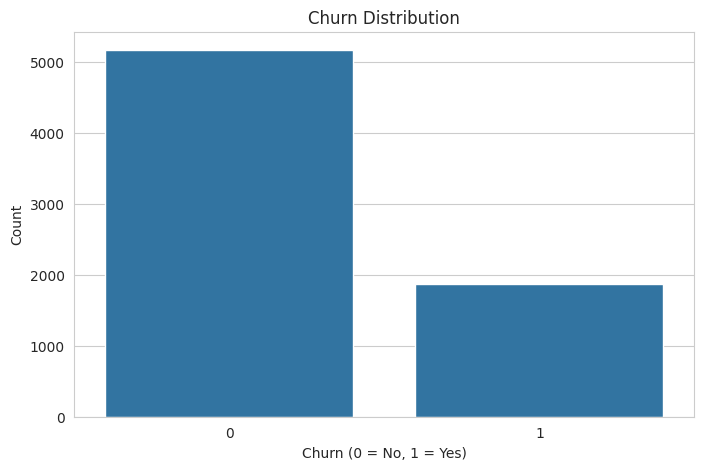

In [9]:
plt.figure()
sns.countplot(x=df["Churn"])
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


Numeric summary:


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000



===== Churn rate by Contract =====


Churn,0,1
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85



===== Churn rate by InternetService =====


...

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20



===== Churn rate by TechSupport =====


Churn,0,1
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20



===== Churn rate by OnlineSecurity =====


Churn,0,1
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


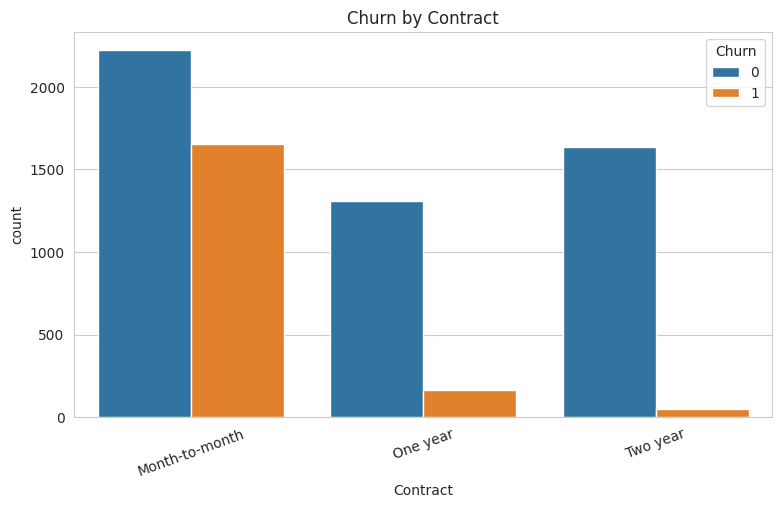

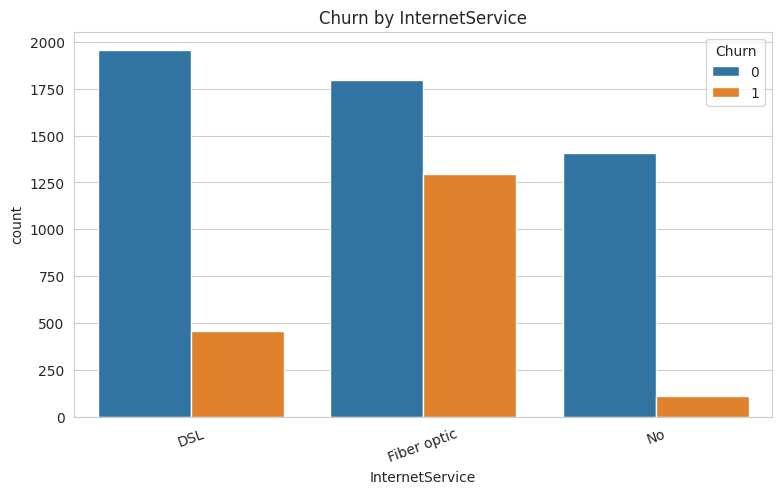

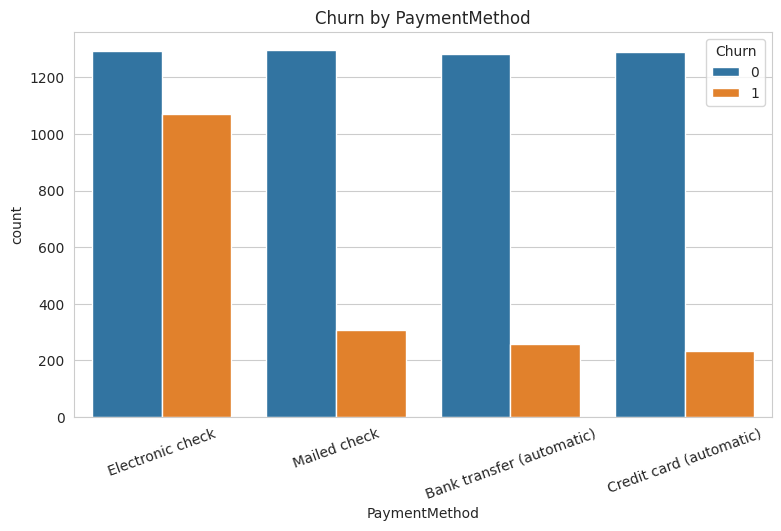

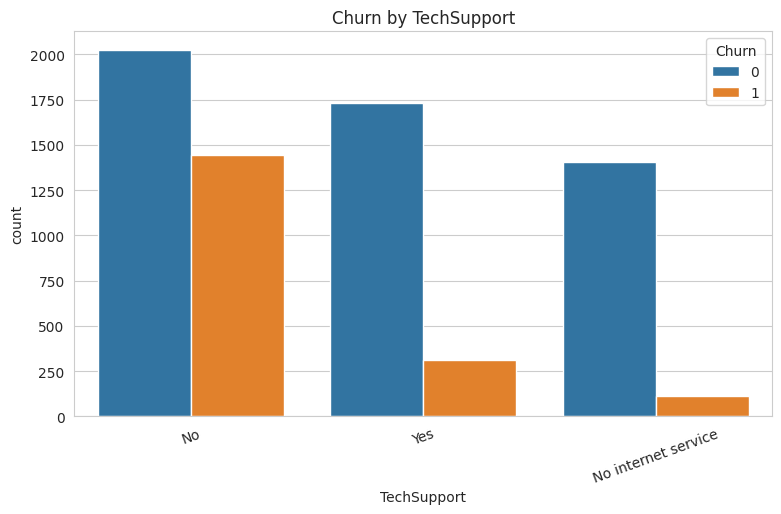

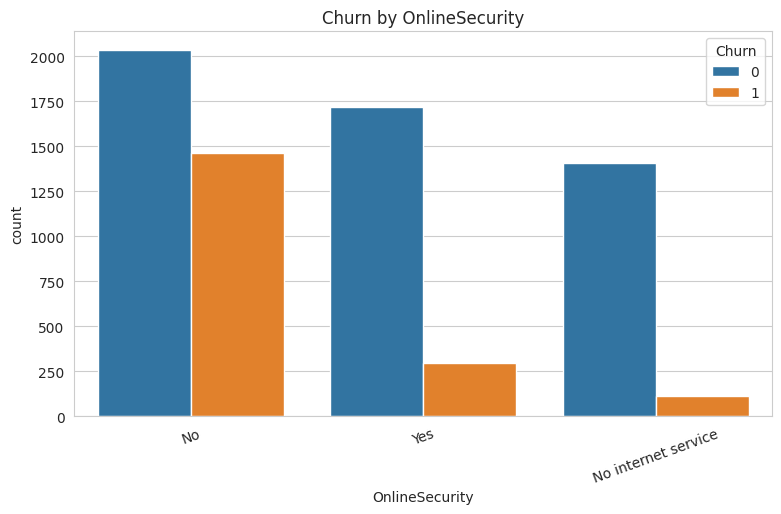

<Figure size 800x500 with 0 Axes>

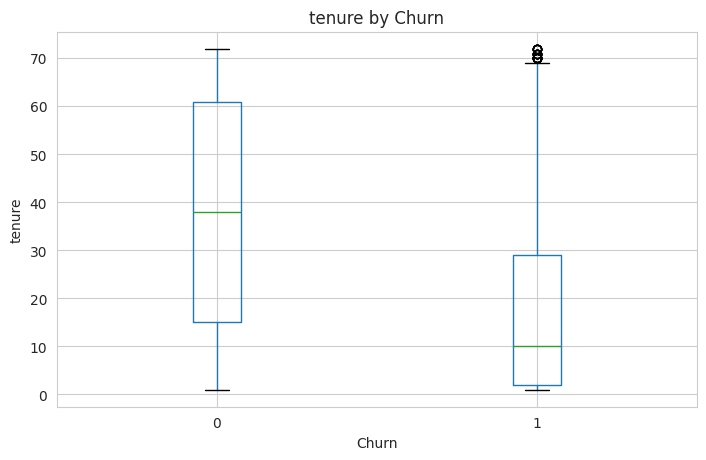

<Figure size 800x500 with 0 Axes>

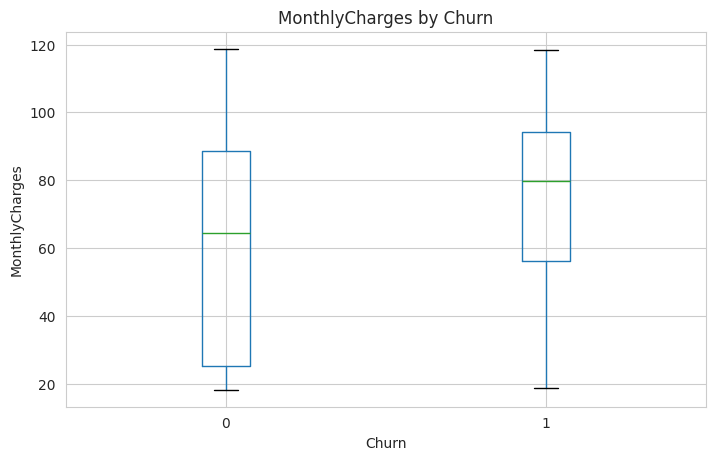

<Figure size 800x500 with 0 Axes>

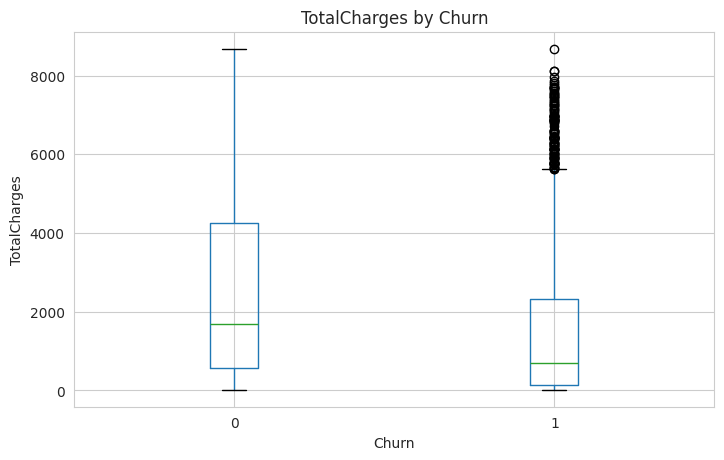

In [10]:
print("\nNumeric summary:")
display(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe())

for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]:
    print(f"\n===== Churn rate by {col} =====")
    display((pd.crosstab(df[col], df["Churn"], normalize="index") * 100).round(2))

for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"Churn by {col}")
    plt.xticks(rotation=20)
    plt.show()

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure()
    df.boxplot(column=col, by="Churn")
    plt.title(f"{col} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [11]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\ny_train distribution:")
print(y_train.value_counts(normalize=True))
print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))


X_train shape: (5625, 19)
X_test shape: (1407, 19)

y_train distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

y_test distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [13]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

print("=== BASELINE LOGISTIC REGRESSION ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))
print("PR-AUC:", average_precision_score(y_test, y_prob_base))

=== BASELINE LOGISTIC REGRESSION ===
Confusion Matrix:
[[917 116]
 [160 214]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8359290473207676
PR-AUC: 0.6228170767081351


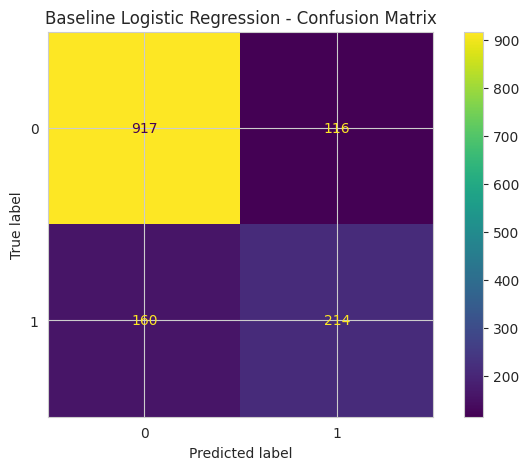

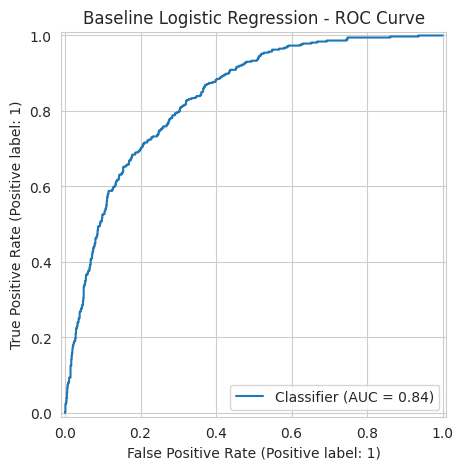

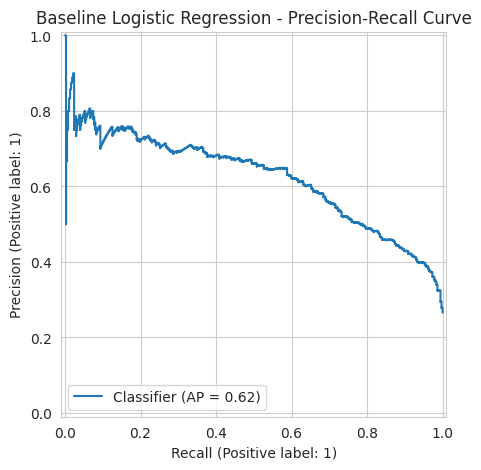

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

=== MODEL COMPARISON ===


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Gradient Boosting,0.640777,0.529412,0.579795,0.838599,0.652086
0,Logistic Regression,0.648485,0.572193,0.607955,0.835929,0.622817
1,Decision Tree,0.602094,0.614973,0.608466,0.829625,0.605857
2,Random Forest,0.634483,0.491979,0.554217,0.813999,0.595383


In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base)
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_base)
plt.title("Baseline Logistic Regression - ROC Curve")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_prob_base)
plt.title("Baseline Logistic Regression - Precision-Recall Curve")
plt.show()

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=42, max_depth=5))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", GradientBoostingClassifier(random_state=42))
    ])
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="PR-AUC", ascending=False)

print("\n=== MODEL COMPARISON ===")
display(results_df)

In [15]:
rf_models = {
    "RF_default": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            n_jobs=-1
        ))
    ]),
    "RF_balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]),
    "RF_depth10": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            n_jobs=-1,
            max_depth=10
        ))
    ]),
    "RF_balanced_depth10": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            n_jobs=-1,
            max_depth=10,
            class_weight="balanced"
        ))
    ])
}

rf_results = []

for name, model in rf_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    rf_results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

rf_results_df = pd.DataFrame(rf_results).sort_values(by="PR-AUC", ascending=False)

print("\n=== RANDOM FOREST TUNING RESULTS ===")
display(rf_results_df)

Training RF_default...
Training RF_balanced...
Training RF_depth10...
Training RF_balanced_depth10...

=== RANDOM FOREST TUNING RESULTS ===


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
2,RF_depth10,0.630719,0.516043,0.567647,0.830180,0.637787
3,RF_balanced_depth10,0.545267,0.708556,0.616279,0.831966,0.633353
0,RF_default,0.634483,0.491979,0.554217,0.813999,0.595383
1,RF_balanced,0.623239,0.473262,0.537994,0.812040,0.588189


In [16]:
best_rf_name = rf_results_df.iloc[0]["Model"]
best_rf = rf_models[best_rf_name]

print("Best RF model:", best_rf_name)

best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("\n=== BEST RANDOM FOREST DETAILS ===")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print("PR-AUC:", average_precision_score(y_test, y_prob_best))

Best RF model: RF_depth10

=== BEST RANDOM FOREST DETAILS ===
[[920 113]
 [181 193]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8301802548001512
PR-AUC: 0.6377866138940813


In [17]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_best >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)

    threshold_results.append({
        "Threshold": thresh,
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1": f1_score(y_test, y_pred_thresh),
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    })

threshold_df = pd.DataFrame(threshold_results)

print("\n=== THRESHOLD TUNING ===")
display(threshold_df)


=== THRESHOLD TUNING ===


,Threshold,Precision,Recall,F1,FP,FN,TP
0,0.1,0.387555,0.949198,0.550388,561,19,355
1,0.2,0.451477,0.858289,0.591705,390,53,321
2,0.3,0.515044,0.778075,0.619808,274,83,291
3,0.4,0.568396,0.644385,0.604010,183,133,241
4,0.5,0.630719,0.516043,0.567647,113,181,193


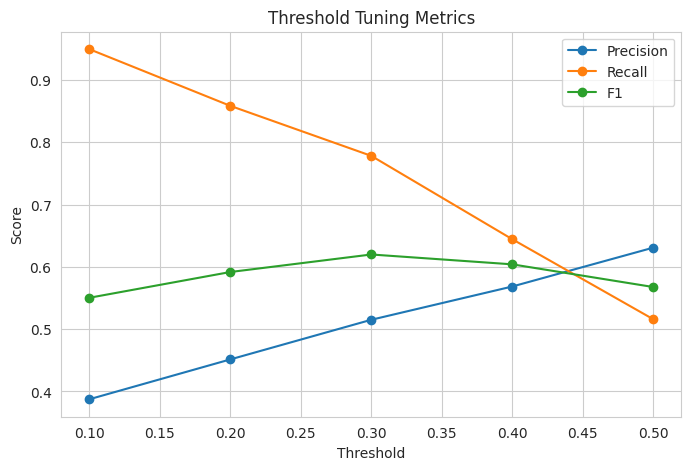

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
plt.title("Threshold Tuning Metrics")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [19]:
best_rf.fit(X_train, y_train)

ohe = best_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(encoded_cat_features)

rf_classifier = best_rf.named_steps["clf"]
feature_importances = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== TOP 20 FEATURE IMPORTANCES ===")
display(feature_importances.head(20))


=== TOP 20 FEATURE IMPORTANCES ===


,Feature,Importance
1,tenure,0.142565
3,TotalCharges,0.124366
36,Contract_Month-to-month,0.094961
2,MonthlyCharges,0.091404
18,OnlineSecurity_No,0.047763
16,InternetService_Fiber optic,0.044915
27,TechSupport_No,0.043210
43,PaymentMethod_Electronic check,0.039221
38,Contract_Two year,0.032163
21,OnlineBackup_No,0.019631


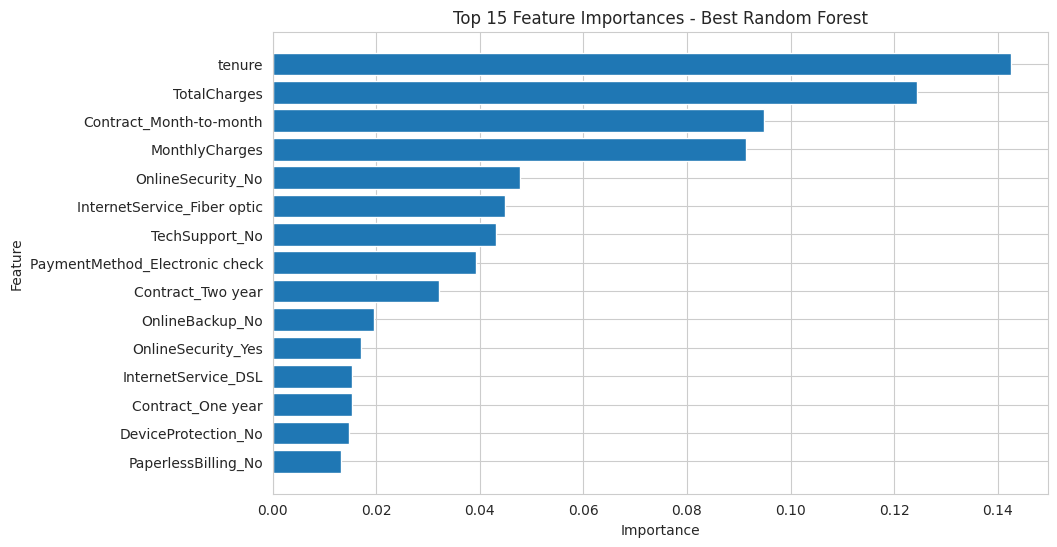

In [20]:
top_n = 15
top_features = feature_importances.head(top_n).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Feature Importances - Best Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
print("\n=== FINAL SUMMARY ===")
print("\nModel comparison:")
display(results_df)

print("\nRandom Forest tuning:")
display(rf_results_df)

print("\nThreshold tuning:")
display(threshold_df)

print("\nTop features:")
display(feature_importances.head(10))


=== FINAL SUMMARY ===

Model comparison:


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Gradient Boosting,0.640777,0.529412,0.579795,0.838599,0.652086
0,Logistic Regression,0.648485,0.572193,0.607955,0.835929,0.622817
1,Decision Tree,0.602094,0.614973,0.608466,0.829625,0.605857
2,Random Forest,0.634483,0.491979,0.554217,0.813999,0.595383



Random Forest tuning:


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
2,RF_depth10,0.630719,0.516043,0.567647,0.830180,0.637787
3,RF_balanced_depth10,0.545267,0.708556,0.616279,0.831966,0.633353
0,RF_default,0.634483,0.491979,0.554217,0.813999,0.595383
1,RF_balanced,0.623239,0.473262,0.537994,0.812040,0.588189



Threshold tuning:


,Threshold,Precision,Recall,F1,FP,FN,TP
0,0.1,0.387555,0.949198,0.550388,561,19,355
1,0.2,0.451477,0.858289,0.591705,390,53,321
2,0.3,0.515044,0.778075,0.619808,274,83,291
3,0.4,0.568396,0.644385,0.604010,183,133,241
4,0.5,0.630719,0.516043,0.567647,113,181,193



Top features:


,Feature,Importance
1,tenure,0.142565
3,TotalCharges,0.124366
36,Contract_Month-to-month,0.094961
2,MonthlyCharges,0.091404
18,OnlineSecurity_No,0.047763
16,InternetService_Fiber optic,0.044915
27,TechSupport_No,0.043210
43,PaymentMethod_Electronic check,0.039221
38,Contract_Two year,0.032163
21,OnlineBackup_No,0.019631
